In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/national-family-health-survey .csv')

In [ ]:
df.head(30)

,id,year,state_name,state_code,district_name,district_code,pop_f_6_sch,pop_below_15,sex_ratio_tot_pop,sex_ratio_child_birth,...,men_bp_mild,men_bp_sev,men_bp_ele_med,cerv_cancer,breast_cancer,oral_cancer,tobaco_women_15,tobaco_men_15,alcohol_women_15,alcohol_men_15
0,0,2019-20,Andaman And Nicobar Islands,35,Nicobars,603,78.0,23.0,973.0,927.0,...,32.9,11.1,47.0,13.4,13.2,5.4,63.5,76.8,29.6,64.5
1,1,2014-15,Andaman And Nicobar Islands,35,Nicobars,603,77.2,25.4,957.0,1060.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2019-20,Andaman And Nicobar Islands,35,North And Middle Andaman,632,82.7,19.8,950.0,844.0,...,22.6,6.0,32.2,1.7,0.3,15.8,46.8,70.5,5.1,45.3
3,3,2014-15,Andaman And Nicobar Islands,35,North And Middle Andaman,632,83.8,22.6,951.0,975.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,2019-20,Andaman And Nicobar Islands,35,South Andamans,602,84.7,21.0,967.0,935.0,...,17.9,6.1,26.9,1.3,0.7,8.0,19.6,50.8,1.7,32.8
5,5,2014-15,Andaman And Nicobar Islands,35,South Andamans,602,85.8,24.2,989.0,794.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,6,2019-20,Andhra Pradesh,28,Anantapur,502,59.5,24.3,1047.0,881.0,...,16.2,7.7,26.7,1.0,0.4,4.0,5.0,20.5,0.6,16.8
7,7,2014-15,Andhra Pradesh,28,Anantapur,502,56.9,24.0,1000.0,1196.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,8,2019-20,Andhra Pradesh,28,East Godavari,505,75.4,20.5,995.0,882.0,...,17.3,7.3,32.2,1.9,1.0,4.8,3.2,25.5,0.7,25.9
9,9,2014-15,Andhra Pradesh,28,East Godavari,505,69.0,21.8,927.0,1008.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.shape

(1267, 110)

In [ ]:
# STEP 1: MISSING VALUE SUMMARY

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_pct})

# Show top columns with missing values
# Show all columns that have any missing values
missing_df[missing_df['Missing Values'] > 0]


,Missing Values,Percentage


Thus there are no missing values

In [ ]:
# STEP 2: SPLIT BY YEAR

df_1415 = df[df['year'] == '2014-15'].copy()
df_1920 = df[df['year'] == '2019-20'].copy()

print("2014-15 shape:", df_1415.shape)
print("2019-20 shape:", df_1920.shape)

2014-15 shape: (569, 110)
2019-20 shape: (698, 110)


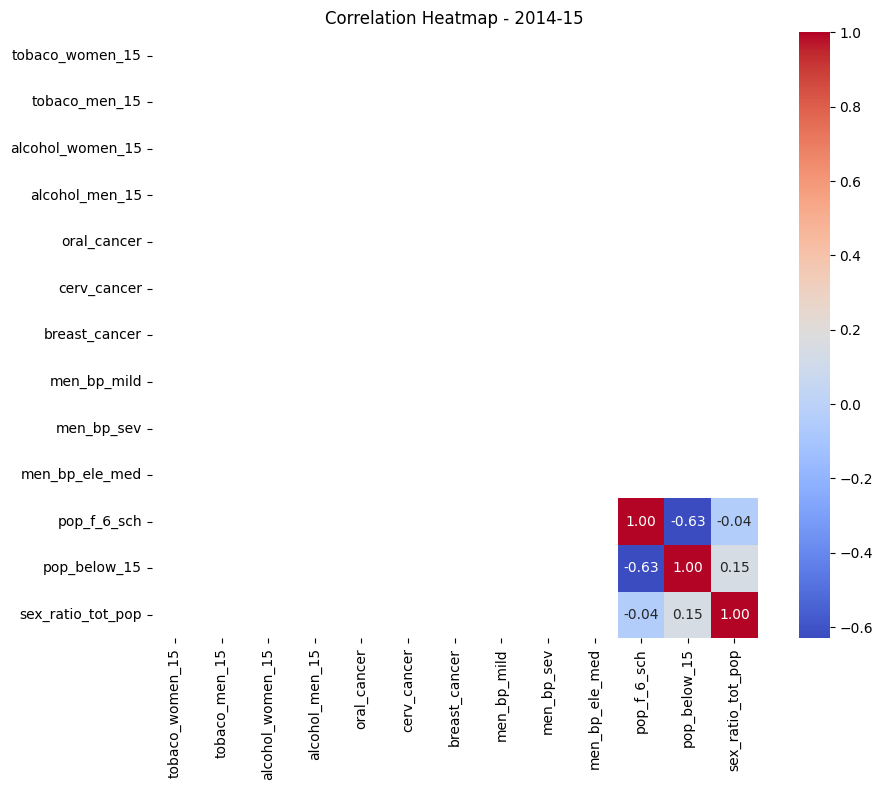

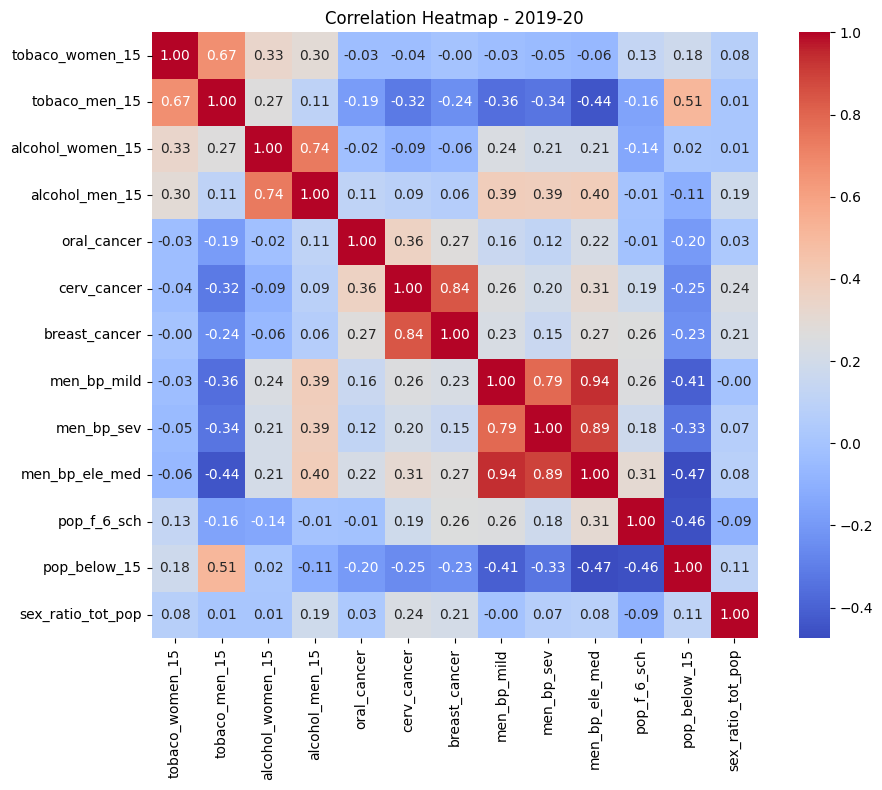

In [ ]:
# STEP 3: CORRELATION HEATMAP FOR EACH YEAR

import seaborn as sns
import matplotlib.pyplot as plt

# Select useful numeric health-related columns
health_vars = [
    'tobaco_women_15', 'tobaco_men_15',
    'alcohol_women_15', 'alcohol_men_15',
    'oral_cancer', 'cerv_cancer', 'breast_cancer',
    'men_bp_mild', 'men_bp_sev', 'men_bp_ele_med',
    'pop_f_6_sch', 'pop_below_15', 'sex_ratio_tot_pop'
]

# Function to plot heatmap
def plot_corr(data, title):
    corr = data[health_vars].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plot for each year
plot_corr(df_1415, "Correlation Heatmap - 2014-15")
plot_corr(df_1920, "Correlation Heatmap - 2019-20")

In [ ]:
# Choose your year’s dataframe and health variables
data = df_1920  # or df_1415 if you want 2014–15
vars_of_interest = [
    'tobaco_women_15', 'tobaco_men_15',
    'alcohol_women_15', 'alcohol_men_15',
    'oral_cancer', 'cerv_cancer', 'breast_cancer',
    'men_bp_mild', 'men_bp_sev', 'men_bp_ele_med',
    'pop_f_6_sch', 'pop_below_15', 'sex_ratio_tot_pop'
]

# Compute correlation matrix
corr_matrix = data[vars_of_interest].corr()

# Flatten the matrix and filter duplicates + self-correlations
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Remove self-pairs and duplicates
filtered = corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]
filtered = filtered.drop_duplicates(subset=['Correlation'])

# Sort by absolute correlation value
strong_corrs = filtered.reindex(filtered['Correlation'].abs().sort_values(ascending=False).index)

# Show top 15
strong_corrs.head(15)

,Feature 1,Feature 2,Correlation
100,men_bp_mild,men_bp_ele_med,0.938495
113,men_bp_sev,men_bp_ele_med,0.894862
71,cerv_cancer,breast_cancer,0.839785
99,men_bp_mild,men_bp_sev,0.789083
29,alcohol_women_15,alcohol_men_15,0.736180
1,tobaco_women_15,tobaco_men_15,0.670684
24,tobaco_men_15,pop_below_15,0.513251
128,men_bp_ele_med,pop_below_15,-0.474444
141,pop_f_6_sch,pop_below_15,-0.457331
22,tobaco_men_15,men_bp_ele_med,-0.444935


1)men_bp_mild & men_bp_ele_med0.94Very strong link: districts with more men having mildly high BP also have more men on medication for elevated BP. Obvious, but confirms progression

2️)men_bp_sev & men_bp_ele_med0.89Severe BP correlates strongly with medical intervention. Again, expected — but helps confirm data quality.

3️)cerv_cancer & breast_cancer0.84Strong: districts with high cervical cancer rates also see high breast cancer. Female health issues cluster. Possibly due to poor awareness or screening.

4️)men_bp_mild & men_bp_sev0.79Mild and severe BP rise together in regions — likely poor health management.

5️)alcohol_women_15 & alcohol_men_150.74Strong social/cultural indicator. Districts where men drink more, women often do too. Shared norms.

6️)tobaco_women_15 & tobaco_men_150.67Similar story: where tobacco use is culturally accepted, both genders show high use

7️)tobaco_men_15 & pop_below_150.51🔥 Interesting: more tobacco use where child population is higher? Could signal less education/awareness or socio-economic burden. Worth investigating

.8️)men_bp_ele_med & pop_below_15-0.47Inverse: districts with younger populations have fewer people on BP meds (likely because BP issues rise with age)

.9️)pop_f_6_sch & pop_below_15-0.46Educated districts → fewer children. Logical: education correlates with lower birthrates.

10)tobaco_men_15 & men_bp_ele_med-0.44🚩 Surprisingly inverse — maybe tobacco-heavy districts don’t access BP medication? Could be poor healthcare access.

1️1)men_bp_mild & pop_below_15-0.40Fewer mild BP cases in districts with high child population (again, younger populations = healthier BP)

.1️2)lcohol_men_15 & men_bp_ele_med0.39Clear pattern: more male alcohol use → more men on BP medication.

13)alcohol_men_15 & men_bp_mild0.39Same as above — early BP impact visible even at mild levels.

14)alcohol_men_15 & men_bp_sev0.39Alcohol might be a direct or contributing factor to worsening BP

15)oral_cancer & cerv_cancer0.36Weak-moderate link — suggests districts with poor screening or healthcare may miss both. Not biologically related, but signals systemic issue.

In [ ]:
# STEP 5: STATE-WISE MEANS FOR 2019–20

# Choose columns of interest
cols = [
    'state_name',
    'tobaco_men_15', 'tobaco_women_15',
    'alcohol_men_15', 'alcohol_women_15',
    'oral_cancer', 'breast_cancer', 'cerv_cancer',
    'men_bp_mild', 'men_bp_sev', 'men_bp_ele_med',
    'pop_f_6_sch'
]

# Group and calculate mean per state
state_summary_1920 = df_1920[cols].groupby('state_name').mean().sort_values('tobaco_men_15', ascending=False)

# Display top 10 states by male tobacco use
state_summary_1920.head(10)

,tobaco_men_15,tobaco_women_15,alcohol_men_15,alcohol_women_15,oral_cancer,breast_cancer,cerv_cancer,men_bp_mild,men_bp_sev,men_bp_ele_med,pop_f_6_sch
state_name,,,,,,,,,,,
Mizoram,74.900000,65.387500,23.100000,0.837500,0.687500,1.850000,5.437500,15.175000,4.800000,22.425000,91.800000
Andaman And Nicobar Islands,66.033333,43.300000,47.533333,12.133333,9.733333,4.733333,5.466667,24.466667,7.733333,35.366667,81.800000
Manipur,60.888889,42.277778,37.377778,1.088889,0.588889,1.000000,1.866667,19.744444,8.511111,30.566667,82.244444
Meghalaya,59.272727,27.872727,34.490909,1.572727,0.354545,0.200000,0.409091,13.772727,3.890909,20.472727,85.027273
Tripura,57.825000,51.225000,33.000000,6.650000,0.537500,0.262500,0.625000,12.937500,4.750000,21.600000,81.100000
Assam,52.948485,22.315152,28.836364,9.593939,0.209091,0.187879,0.230303,13.887879,4.772727,21.330303,77.830303
Odisha,51.313333,25.416667,29.666667,4.330000,0.226667,0.186667,0.823333,16.603333,6.026667,25.060000,70.216667
Arunachal Pradesh,49.375000,18.165000,53.035000,23.865000,0.550000,0.370000,0.785000,22.970000,9.235000,33.420000,69.740000
Nagaland,49.063636,12.454545,23.381818,0.836364,0.372727,0.372727,0.363636,20.436364,8.990909,30.109091,83.772727


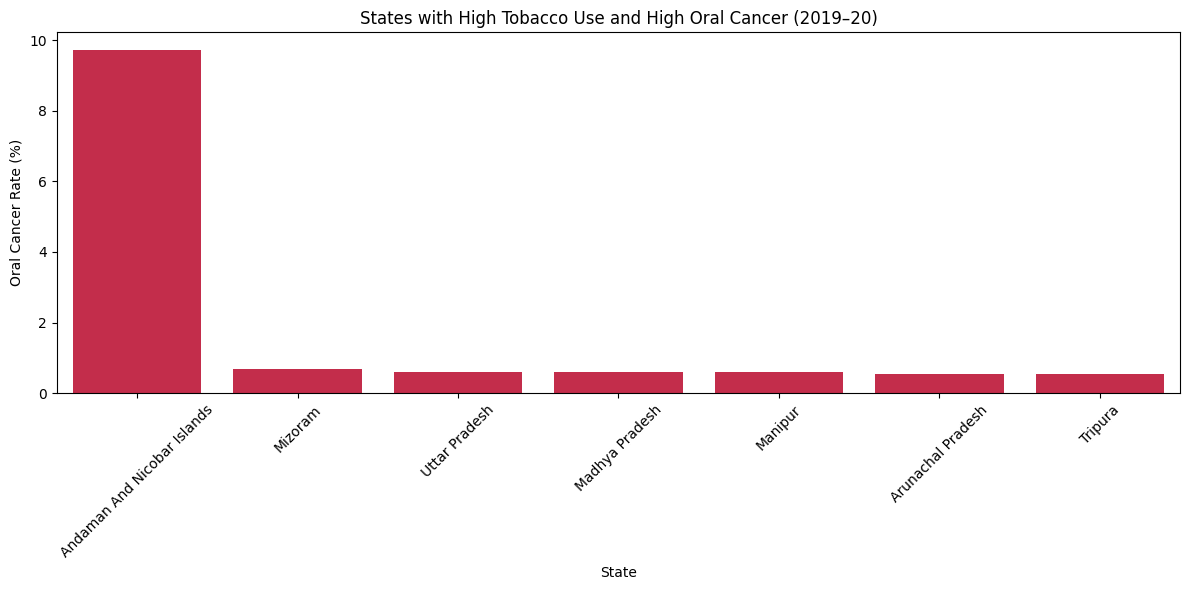

In [ ]:
# Filter states with BOTH high tobacco and high oral cancer
high_tob_cancer = state_summary_1920[
    (state_summary_1920['tobaco_men_15'] > 40) &
    (state_summary_1920['oral_cancer'] > 0.5)
].sort_values('oral_cancer', ascending=False).reset_index()

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(data=high_tob_cancer, x='state_name', y='oral_cancer', color='crimson')
plt.xticks(rotation=45)
plt.title("States with High Tobacco Use and High Oral Cancer (2019–20)")
plt.ylabel("Oral Cancer Rate (%)")
plt.xlabel("State")
plt.tight_layout()
plt.show()

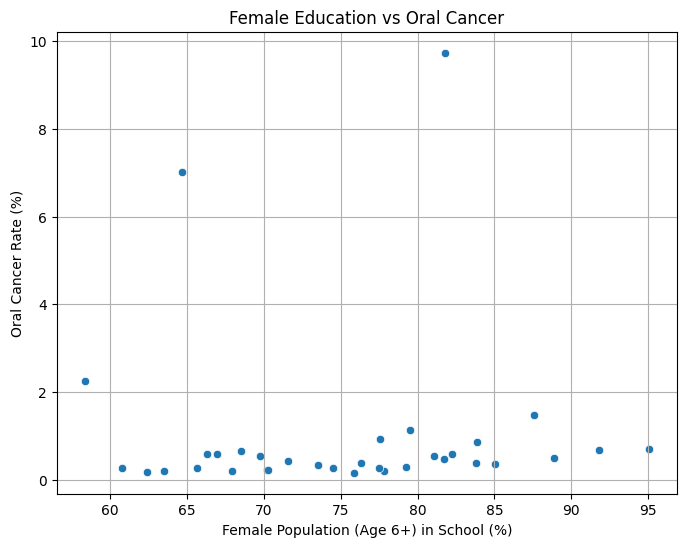

In [ ]:
# Scatter plot to see inverse relationship (if any)
plt.figure(figsize=(8,6))
sns.scatterplot(data=state_summary_1920, x='pop_f_6_sch', y='oral_cancer')
plt.title("Female Education vs Oral Cancer")
plt.xlabel("Female Population (Age 6+) in School (%)")
plt.ylabel("Oral Cancer Rate (%)")
plt.grid(True)
plt.show()

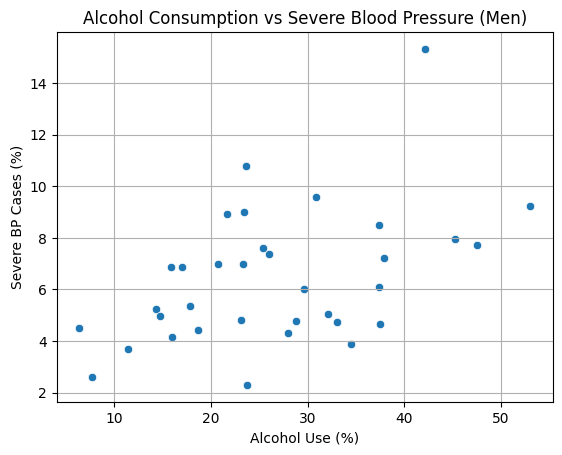

In [ ]:
sns.scatterplot(data=state_summary_1920, x='alcohol_men_15', y='men_bp_sev')
plt.title("Alcohol Consumption vs Severe Blood Pressure (Men)")
plt.xlabel("Alcohol Use (%)")
plt.ylabel("Severe BP Cases (%)")
plt.grid(True)
plt.show()

##COMPARING CORRELATIONS

In [ ]:
# STEP 6A - Compare same pair correlations across years

# 1. Define health variables
health_vars = [
    'tobaco_women_15', 'tobaco_men_15',
    'alcohol_women_15', 'alcohol_men_15',
    'oral_cancer', 'cerv_cancer', 'breast_cancer',
    'men_bp_mild', 'men_bp_sev', 'men_bp_ele_med',
    'pop_f_6_sch', 'pop_below_15', 'sex_ratio_tot_pop'
]

# 2. Compute correlation matrices for each year
corr_1415 = df_1415[health_vars].corr()
corr_1920 = df_1920[health_vars].corr()

# 3. Flatten the matrices
flat_1415 = corr_1415.unstack().reset_index()
flat_1920 = corr_1920.unstack().reset_index()
flat_1415.columns = ['Feature 1', 'Feature 2', 'Correlation_1415']
flat_1920.columns = ['Feature 1', 'Feature 2', 'Correlation_1920']

# 4. Merge and filter duplicates and self-pairs
merged = pd.merge(flat_1415, flat_1920, on=['Feature 1', 'Feature 2'])
merged = merged[merged['Feature 1'] != merged['Feature 2']]
merged = merged.drop_duplicates(subset=['Feature 1', 'Feature 2'])

# 5. Calculate delta correlation
merged['Δ Correlation'] = merged['Correlation_1920'] - merged['Correlation_1415']

# 6. Sort by largest absolute shift
comparison_table = merged.sort_values(by='Δ Correlation', key=abs, ascending=False)

# 7. Show top shifts
comparison_table.head(20)

,Feature 1,Feature 2,Correlation_1415,Correlation_1920,Δ Correlation
141,pop_f_6_sch,pop_below_15,-0.630273,-0.457331,0.172942
153,pop_below_15,pop_f_6_sch,-0.630273,-0.457331,0.172942
142,pop_f_6_sch,sex_ratio_tot_pop,-0.042653,-0.091931,-0.049278
166,sex_ratio_tot_pop,pop_f_6_sch,-0.042653,-0.091931,-0.049278
155,pop_below_15,sex_ratio_tot_pop,0.145420,0.110426,-0.034994
167,sex_ratio_tot_pop,pop_below_15,0.145420,0.110426,-0.034994
1,tobaco_women_15,tobaco_men_15,NaN,0.670684,NaN
2,tobaco_women_15,alcohol_women_15,NaN,0.332594,NaN
3,tobaco_women_15,alcohol_men_15,NaN,0.297173,NaN
4,tobaco_women_15,oral_cancer,NaN,-0.034699,NaN


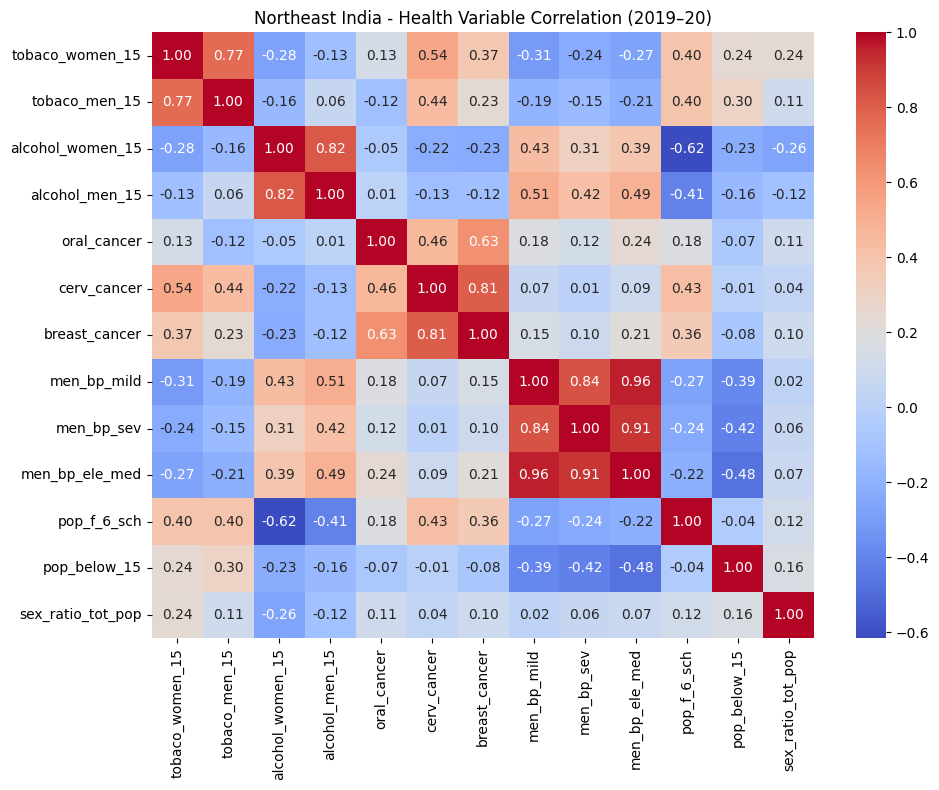

In [ ]:
# STEP 6B - Region-wise correlation matrix (Northeast India)

# Define NE states (adjust as needed)
ne_states = [
    'Assam', 'Manipur', 'Mizoram', 'Nagaland',
    'Tripura', 'Meghalaya', 'Arunachal Pradesh'
]

# Filter dataset for NE states
ne_data = df_1920[df_1920['state_name'].isin(ne_states)]

# Use same health variable list as before
health_vars = [
    'tobaco_women_15', 'tobaco_men_15',
    'alcohol_women_15', 'alcohol_men_15',
    'oral_cancer', 'cerv_cancer', 'breast_cancer',
    'men_bp_mild', 'men_bp_sev', 'men_bp_ele_med',
    'pop_f_6_sch', 'pop_below_15', 'sex_ratio_tot_pop'
]

# Compute correlation matrix
ne_corr = ne_data[health_vars].corr()

# Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(ne_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Northeast India - Health Variable Correlation (2019–20)")
plt.tight_layout()
plt.show()

#Checking for sign flips from 14-15 to 19-20

In [ ]:
merged.head()

,Feature 1,Feature 2,Correlation_1415,Correlation_1920,Δ Correlation
1,tobaco_women_15,tobaco_men_15,NaN,0.670684,NaN
2,tobaco_women_15,alcohol_women_15,NaN,0.332594,NaN
3,tobaco_women_15,alcohol_men_15,NaN,0.297173,NaN
4,tobaco_women_15,oral_cancer,NaN,-0.034699,NaN
5,tobaco_women_15,cerv_cancer,NaN,-0.035978,NaN


In [ ]:
merged = merged.dropna(subset=['Correlation_1415', 'Correlation_1920'])

In [ ]:
merged['Δ Correlation'] = merged['Correlation_1920'] - merged['Correlation_1415']
merged['Sign Flip'] = (merged['Correlation_1415'] * merged['Correlation_1920']) < 0

In [ ]:
print("Total sign flips:", merged['Sign Flip'].sum())

Total sign flips: 0


In [ ]:
# Show top pairs with biggest changes
merged['Δ Correlation'] = merged['Correlation_1920'] - merged['Correlation_1415']
merged['Change Magnitude'] = merged['Δ Correlation'].abs()

merged.sort_values('Change Magnitude', ascending=False).head(10)

,Feature 1,Feature 2,Correlation_1415,Correlation_1920,Δ Correlation,Sign Flip,Change Magnitude
141,pop_f_6_sch,pop_below_15,-0.630273,-0.457331,0.172942,False,0.172942
153,pop_below_15,pop_f_6_sch,-0.630273,-0.457331,0.172942,False,0.172942
142,pop_f_6_sch,sex_ratio_tot_pop,-0.042653,-0.091931,-0.049278,False,0.049278
166,sex_ratio_tot_pop,pop_f_6_sch,-0.042653,-0.091931,-0.049278,False,0.049278
155,pop_below_15,sex_ratio_tot_pop,0.145420,0.110426,-0.034994,False,0.034994
167,sex_ratio_tot_pop,pop_below_15,0.145420,0.110426,-0.034994,False,0.034994


#Plotting highest correlation delta

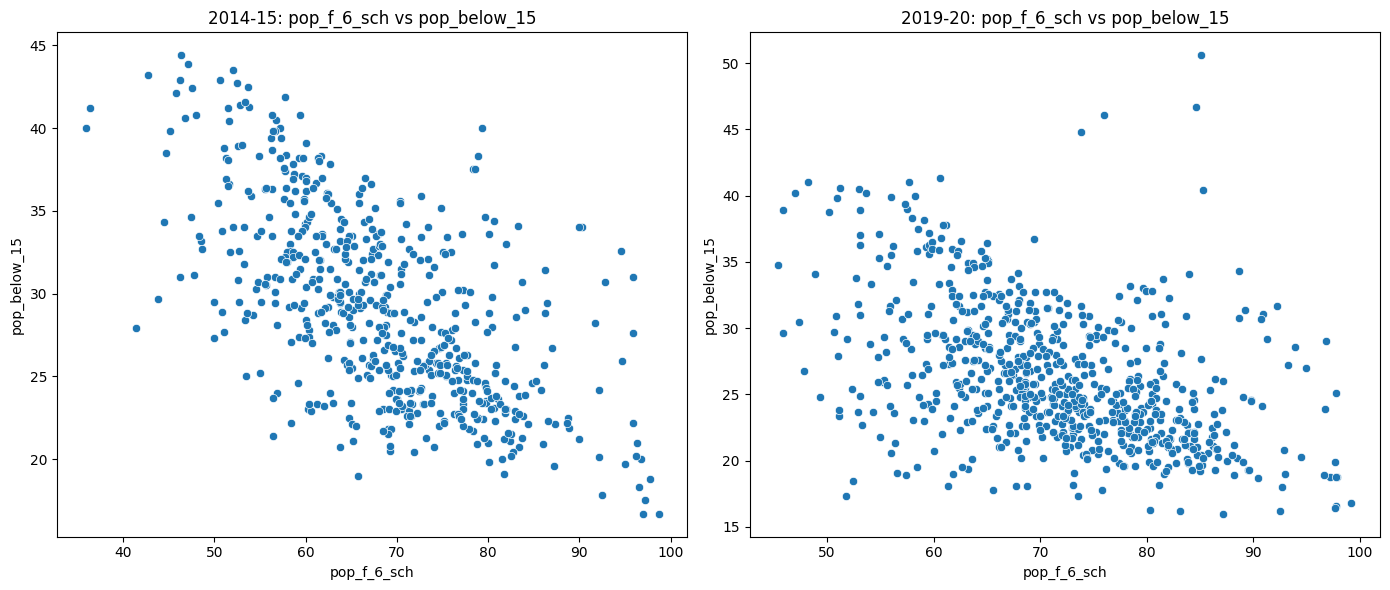

In [ ]:
x = 'pop_f_6_sch'
y = 'pop_below_15'

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df_1415, x=x, y=y, ax=axs[0])
axs[0].set_title(f'2014-15: {x} vs {y}')

sns.scatterplot(data=df_1920, x=x, y=y, ax=axs[1])
axs[1].set_title(f'2019-20: {x} vs {y}')

plt.tight_layout()
plt.show()

In 2014–15, there was a strong negative correlation between female schooling (pop_f_6_sch) and the percentage of population below age 15, meaning that as more girls attended school, birth rates were lower—indicating effective awareness and family planning. However, by 2019–20, while the overall trend remained negative, the correlation had weakened. The data points became more scattered, suggesting that female education alone no longer explained birth rate patterns as strongly, likely due to the influence of additional social, economic, or healthcare factors over time.

In [ ]:
vars_to_check = [
    'pop_below_15', 'pop_f_6_sch', 'tobaco_men_15',
    'alcohol_men_15', 'oral_cancer', 'men_bp_sev'
]

for target in vars_to_check:
    for col in ['birth_rate', 'death_rate']:
        if col in df_1920.columns:
            corr = df_1920[[col, target]].corr().iloc[0, 1]
            print(f"{col} ↔ {target}: correlation = {corr:.2f}")

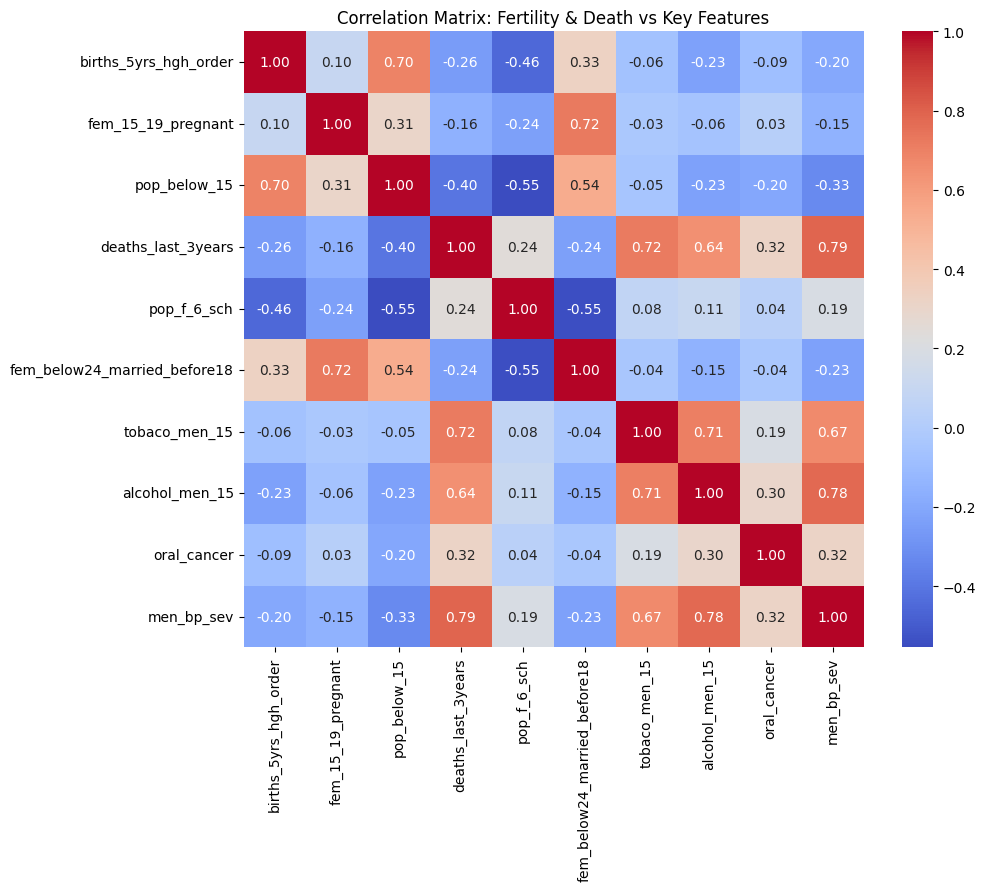

In [ ]:
fertility_cols = [
    'births_5yrs_hgh_order', 'fem_15_19_pregnant', 'pop_below_15'
]

death_cols = ['deaths_last_3years']

selected_cols = fertility_cols + death_cols + [
    'pop_f_6_sch', 'fem_below24_married_before18',
    'tobaco_men_15', 'alcohol_men_15',
    'oral_cancer', 'men_bp_sev'
]

corr_df = df[selected_cols].dropna()
corr_matrix = corr_df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Fertility & Death vs Key Features")
plt.show()

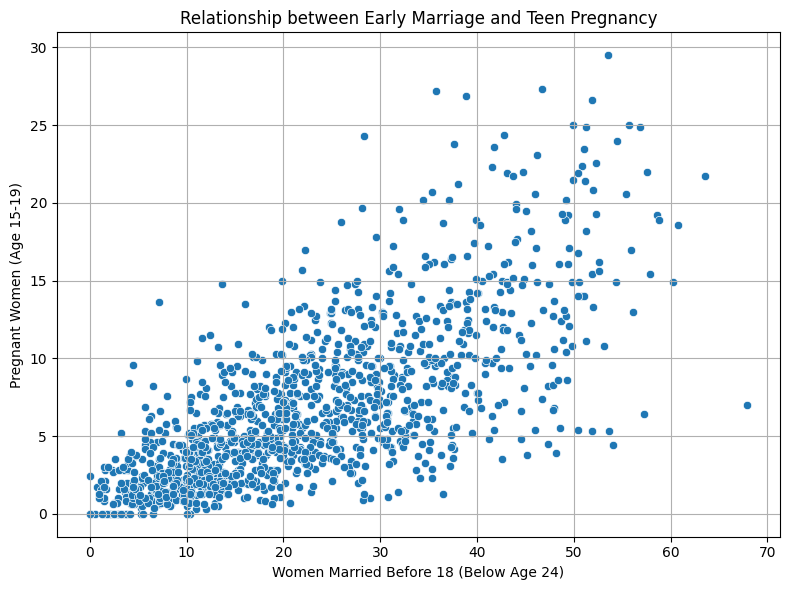

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing values from both columns
plot_df = df[['fem_15_19_pregnant', 'fem_below24_married_before18']].dropna()

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='fem_below24_married_before18', y='fem_15_19_pregnant')

plt.title('Relationship between Early Marriage and Teen Pregnancy')
plt.xlabel('Women Married Before 18 (Below Age 24)')
plt.ylabel('Pregnant Women (Age 15-19)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nNon-numeric columns:")
print(non_numeric_cols)


Non-numeric columns:
['year', 'state_name', 'district_name']


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert 'year' to numeric (if not already)
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Drop 'district_name' since it's an identifier
df.drop(columns=['district_name'], inplace=True)

# Encode 'state_name'
le = LabelEncoder()
df['state_name'] = le.fit_transform(df['state_name'])

print("✅ Encoded 'state_name', dropped 'district_name', converted 'year'.")
print(df[['year', 'state_name']].head())


✅ Encoded 'state_name', dropped 'district_name', converted 'year'.
   year  state_name
0   NaN           0
1   NaN           0
2   NaN           0
3   NaN           0
4   NaN           0


Target seems continuous — balancing not needed.


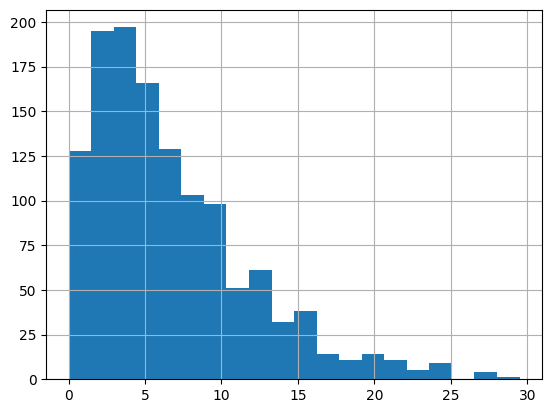

In [ ]:
target = 'fem_15_19_pregnant'

if df[target].dtype == 'object' or df[target].nunique() <= 10:
    print("Target seems categorical, checking balance:")
    print(df[target].value_counts(normalize=True) * 100)
else:
    print("Target seems continuous — balancing not needed.")
    df[target].hist(bins=20)


In [ ]:
# check top correlated numeric features with the target
corr = df.corr(numeric_only=True)[target].sort_values(ascending=False)
print("Top correlated features with target:")
print(corr.head(10))


Top correlated features with target:
fem_15_19_pregnant              1.000000
fem_below24_married_before18    0.724739
fp_pill                         0.330513
pop_below_15                    0.305042
wom_bmi_normal                  0.300551
child_5_underweight             0.297411
child_5_stunted                 0.279556
wom_preg_15_49_anaemic          0.253112
wom_15_49_anaemic               0.221993
non_preg_15_49_anaemic          0.215964
Name: fem_15_19_pregnant, dtype: float64


#MODEL

In [ ]:
from sklearn.model_selection import train_test_split

# Define predictor lists
# Simple regression: strongest single correlation
simple_predictor = ['fem_below24_married_before18']

# Multiple regression: top meaningful correlated variables
predictors = [
    'fem_below24_married_before18',
    'fp_pill',
    'pop_below_15',
    'child_5_underweight',
    'wom_preg_15_49_anaemic'
]

target = 'fem_15_19_pregnant'

# --- Simple Linear Regression split ---
X_simple = df[simple_predictor].dropna()
y_simple = df.loc[X_simple.index, target]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)
print("✅ Simple Regression Shapes:", X_train_s.shape, y_train_s.shape)

# --- Multiple Linear Regression split ---
X_multi = df[predictors].dropna()
y_multi = df.loc[X_multi.index, target]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
print("✅ Multiple Regression Shapes:", X_train_m.shape, y_train_m.shape)


✅ Simple Regression Shapes: (1013, 1) (1013,)
✅ Multiple Regression Shapes: (1013, 5) (1013,)


📈 Simple Linear Regression Results
----------------------------------
Intercept: 0.371
Coefficient: 0.286
R² Score (Test): 0.447
RMSE (Test): 3.502


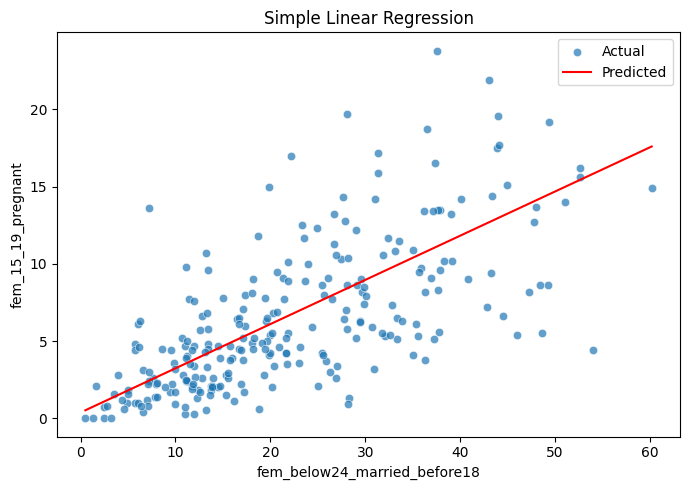

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Initialize model
simple_lr = LinearRegression()

# Train the model
simple_lr.fit(X_train_s, y_train_s)

# Predict on test data
y_pred_s = simple_lr.predict(X_test_s)

# Evaluate
r2_s = r2_score(y_test_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))

print("📈 Simple Linear Regression Results")
print("----------------------------------")
print(f"Intercept: {simple_lr.intercept_:.3f}")
print(f"Coefficient: {simple_lr.coef_[0]:.3f}")
print(f"R² Score (Test): {r2_s:.3f}")
print(f"RMSE (Test): {rmse_s:.3f}")

# Visualize
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_test_s.iloc[:,0], y=y_test_s, label='Actual', alpha=0.7)
sns.lineplot(x=X_test_s.iloc[:,0], y=y_pred_s, color='red', label='Predicted')
plt.xlabel('fem_below24_married_before18')
plt.ylabel('fem_15_19_pregnant')
plt.title('Simple Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()


A simple linear regression was performed using the percentage of women married before age 18 (fem_below24_married_before18) to predict the percentage of teenage pregnancies (fem_15_19_pregnant) across districts.

The model yielded an intercept of 0.37 and a slope coefficient of 0.29. This implies that for every 1% rise in early marriages, the teen pregnancy rate increases by approximately 0.29%.

The model achieved an R² score of 0.447, indicating that early marriage alone explains about 45% of the variation in teenage pregnancy rates. Although this is a moderately strong relationship, it suggests that other social, economic, or health-related factors also play significant roles.

The RMSE of 3.5% suggests moderate predictive accuracy — average predictions deviate from actual teen pregnancy rates by roughly 3.5 percentage points.

Overall, these results provide empirical support for the hypothesis that early marriage is a strong driver of adolescent pregnancy in India, aligning with both prior NFHS findings and literature in public health demographics.

#MULTIPLE LINEAR REGRESSION

In [ ]:
# Predictors for multiple regression
predictors = [
    'fem_below24_married_before18',
    'fp_pill',
    'pop_below_15',
    'child_5_underweight',
    'wom_preg_15_49_anaemic'
]
target = 'fem_15_19_pregnant'

X_multi = df[predictors].dropna()
y_multi = df.loc[X_multi.index, target]

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

multi_lr = LinearRegression()
multi_lr.fit(X_multi, y_multi)
y_pred_m = multi_lr.predict(X_multi)

r2_m = r2_score(y_multi, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_multi, y_pred_m))

print("📊 Multiple Linear Regression Results")
print("-----------------------------------")
print("Intercept:", round(multi_lr.intercept_,3))
print("Coefficients:")
for name, coef in zip(predictors, multi_lr.coef_):
    print(f"{name}: {coef:.3f}")
print(f"R² (Overall): {r2_m:.3f}")
print(f"RMSE: {rmse_m:.3f}")


📊 Multiple Linear Regression Results
-----------------------------------
Intercept: 2.442
Coefficients:
fem_below24_married_before18: 0.299
fp_pill: 0.147
pop_below_15: -0.087
child_5_underweight: -0.031
wom_preg_15_49_anaemic: 0.006
R² (Overall): 0.587
RMSE: 3.304


/tmp/ipython-input-3427232192.py:11: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


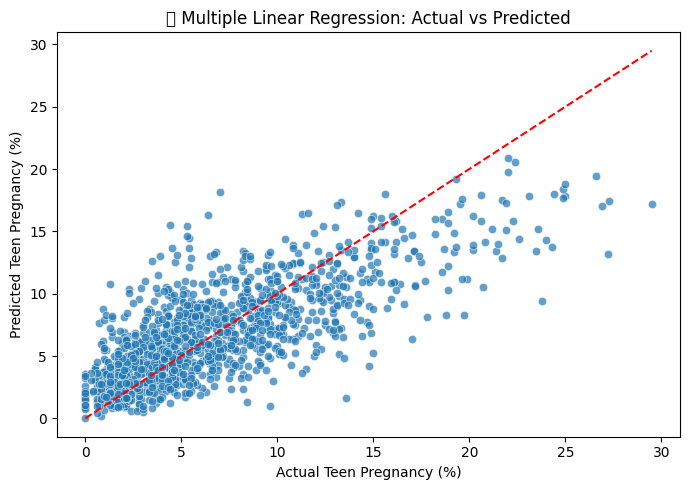

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicted vs Actual
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_multi, y=y_pred_m, alpha=0.7)
plt.plot([y_multi.min(), y_multi.max()], [y_multi.min(), y_multi.max()], color='red', linestyle='--')
plt.xlabel("Actual Teen Pregnancy (%)")
plt.ylabel("Predicted Teen Pregnancy (%)")
plt.title("📊 Multiple Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()


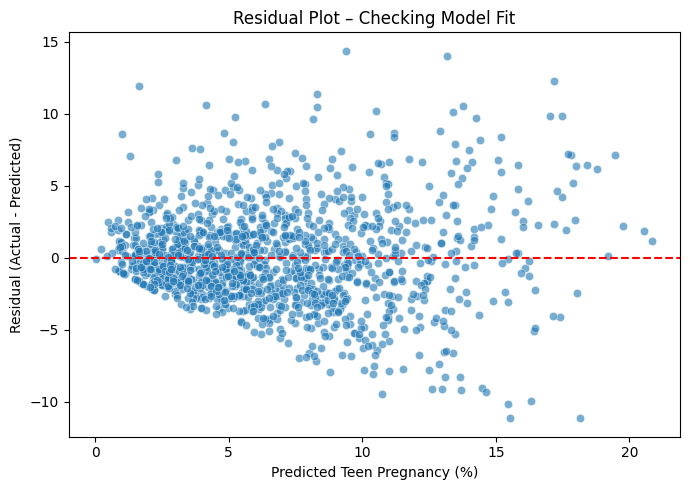

In [ ]:
residuals = y_multi - y_pred_m

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred_m, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Teen Pregnancy (%)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot – Checking Model Fit")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3084062949.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')


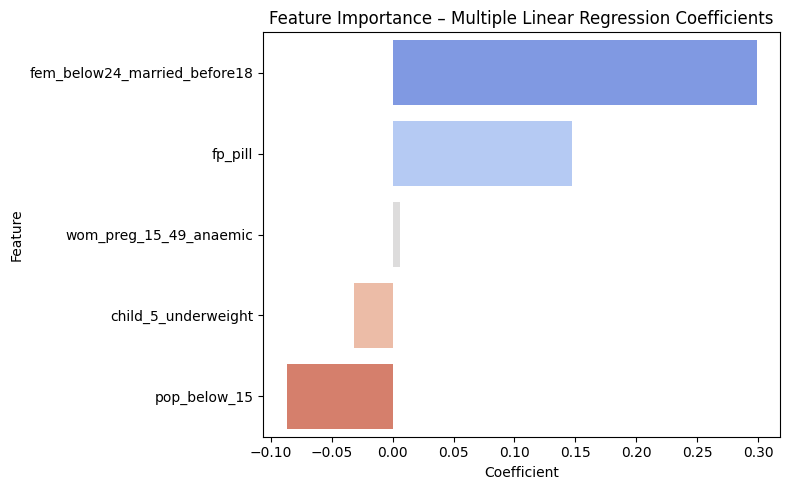

In [ ]:
coef_df = pd.DataFrame({
    'Feature': predictors,
    'Coefficient': multi_lr.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')
plt.title("Feature Importance – Multiple Linear Regression Coefficients")
plt.tight_layout()
plt.show()


Adding 4 additional predictors improved R² from 0.447 → 0.587

RMSE reduced from 3.50 → 3.30

So the model now fits ~30% better overall.

#CLUSTERING

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

features_behavioral = [
    'tobaco_men_15',
    'alcohol_men_15',
    'men_bp_sev',
    'tobaco_women_15',
    'alcohol_women_15',
    'oral_cancer',
    'cerv_cancer'
]

Xb = df[features_behavioral].dropna()
scaler = StandardScaler()
Xb_scaled = scaler.fit_transform(Xb)


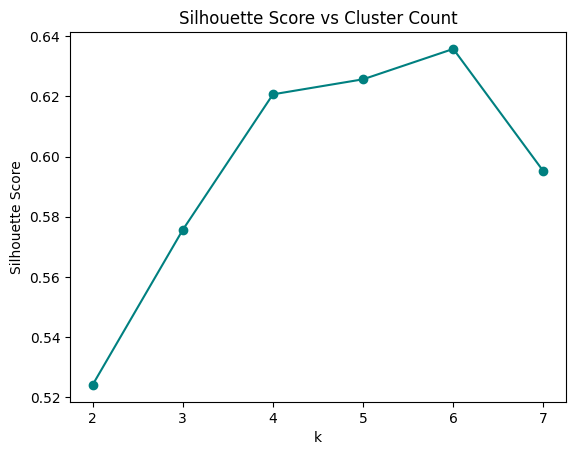

✅ Best k = 6


In [ ]:
sil = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xb_scaled)
    sil.append(silhouette_score(Xb_scaled, labels))

plt.plot(K, sil, 'o-', color='teal')
plt.title('Silhouette Score vs Cluster Count')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.show()

best_k = K[sil.index(max(sil))]
print("✅ Best k =", best_k)


In [ ]:
kmeans_b = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels_b = kmeans_b.fit_predict(Xb_scaled)
Xb['cluster'] = labels_b


In [ ]:
cluster_centers_b = pd.DataFrame(
    scaler.inverse_transform(kmeans_b.cluster_centers_),
    columns=features_behavioral
)
print(cluster_centers_b.round(2))


   tobaco_men_15  alcohol_men_15  men_bp_sev  tobaco_women_15  \
0           0.06            0.00        0.00             0.00   
1          59.23           27.91        5.84            40.36   
2          50.16           49.07        7.75            20.75   
3          21.27           30.79        7.67             5.18   
4          30.42           26.42        7.23            10.09   
5          39.24           18.63        5.71             7.83   

   alcohol_women_15  oral_cancer  cerv_cancer  
0              0.00         0.00         0.00  
1              2.76         0.44         1.50  
2             19.60         0.53         0.84  
3              1.70         1.80         9.77  
4              0.97        10.20         5.29  
5              0.95         0.48         0.92  


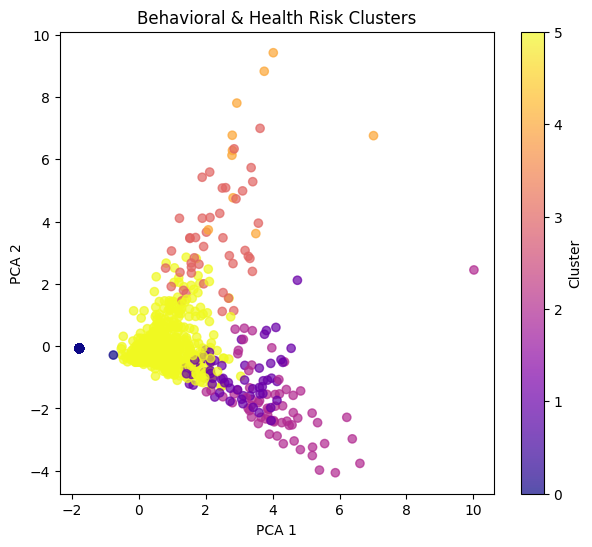

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
Xb_pca = pca.fit_transform(Xb_scaled)

plt.figure(figsize=(7,6))
plt.scatter(Xb_pca[:,0], Xb_pca[:,1], c=labels_b, cmap='plasma', alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Behavioral & Health Risk Clusters')
plt.colorbar(label='Cluster')
plt.show()


Step 6: Check if health outcomes differ across clusters

We can test if cancer prevalence or BP severity differs significantly among clusters.

In [ ]:
from scipy.stats import f_oneway

for var in ['oral_cancer', 'cerv_cancer', 'men_bp_sev']:
    groups = [Xb[Xb.cluster==c][var] for c in sorted(Xb.cluster.unique())]
    f, p = f_oneway(*groups)
    print(f"{var}: F={f:.2f}, p={p:.4f}")


oral_cancer: F=545.52, p=0.0000
cerv_cancer: F=501.47, p=0.0000
men_bp_sev: F=707.37, p=0.0000


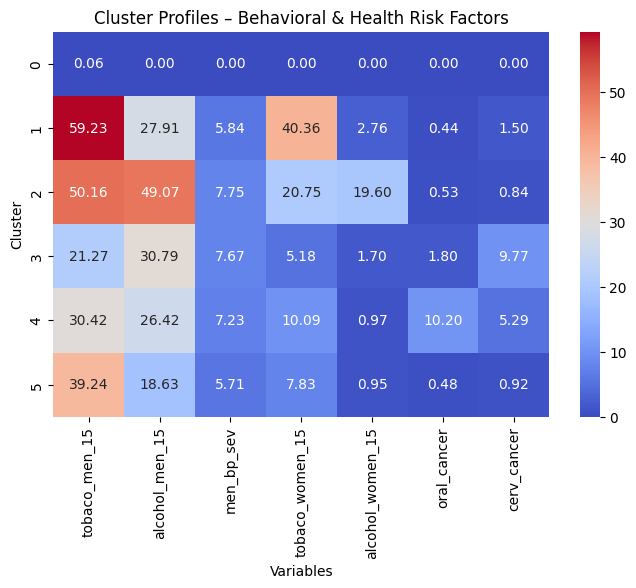

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_centers_b = pd.DataFrame(
    scaler.inverse_transform(kmeans_b.cluster_centers_),
    columns=features_behavioral
)
plt.figure(figsize=(8,5))
sns.heatmap(cluster_centers_b, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Cluster Profiles – Behavioral & Health Risk Factors")
plt.xlabel("Variables")
plt.ylabel("Cluster")
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
X = df[predictors].dropna()
y = df.loc[X.index, 'fem_15_19_pregnant']

rf = RandomForestRegressor(n_estimators=200, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
print("CV R2:", cross_val_score(rf, X, y, cv=cv, scoring='r2').mean())
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)


CV R2: 0.6270042768063709
fem_below24_married_before18    0.606205
fp_pill                         0.159936
pop_below_15                    0.080835
child_5_underweight             0.080597
wom_preg_15_49_anaemic          0.072427
dtype: float64


In [ ]:
df=pd.read_csv('/content/national-family-health-survey .csv')
# Aggregate to state means (replace 'state' with your state column name)
state_df = df.groupby('state_name')[features_behavioral + [
    'fem_below24_married_before18','fem_15_19_pregnant']].mean().dropna()

# Standardize and cluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
scaler = StandardScaler()
S = scaler.fit_transform(state_df)
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=20).fit(S)
state_df['cluster'] = km.labels_

# Visualize
state_df[['cluster', 'fem_15_19_pregnant']].sort_values('cluster')

,cluster,fem_15_19_pregnant
state_name,,
Andaman And Nicobar Islands,0,3.766667
Arunachal Pradesh,0,6.970968
Delhi,0,3.418182
Chhattisgarh,0,3.974359
Sikkim,0,3.375000
Telangana,0,6.373333
Goa,1,2.925000
Jammu And Kashmir,1,2.120000
Ladakh,1,0.575000


WOMENS EMPOWERMENT CLUSTERING

Silhouette scores: {2: np.float64(0.29579858965368155), 3: np.float64(0.30815423728867924), 4: np.float64(0.2804452349241781), 5: np.float64(0.276873460180402), 6: np.float64(0.2383828116222284)}
Best k: 3


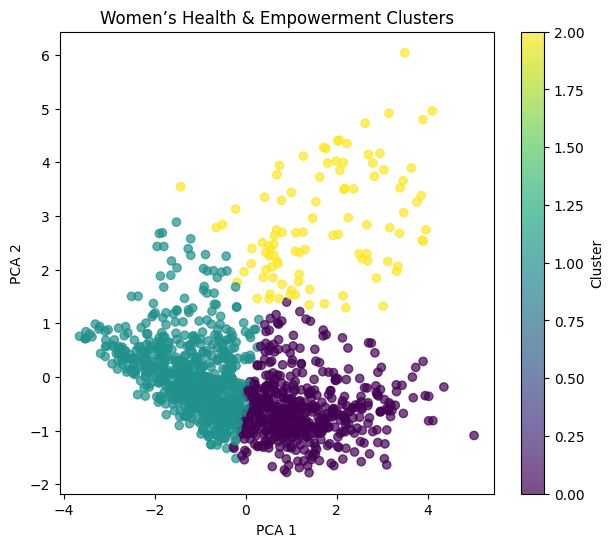

Cluster Centers:
    pop_f_6_sch  fem_below24_married_before18  fem_15_19_pregnant  fp_pill  \
0        61.30                         32.74                8.90     2.59   
1        75.83                         12.84                3.89     3.70   
2        75.70                         34.75               14.96    25.11   

   wom_preg_15_49_anaemic  
0                   54.48  
1                   31.53  
2                   49.74  


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

features_empower = [
    'pop_f_6_sch',  # female schooling
    'fem_below24_married_before18',  # early marriage
    'fem_15_19_pregnant',  # teen pregnancy
    'fp_pill',  # contraceptive use
    'wom_preg_15_49_anaemic'  # anaemia
]

Xw = df[features_empower].dropna()
scaler = StandardScaler()
Xw_scaled = scaler.fit_transform(Xw)

# find best k
sil = {}
for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(Xw_scaled)
    sil[k] = silhouette_score(Xw_scaled, labels)
print("Silhouette scores:", sil)
best_k = max(sil, key=sil.get)
print("Best k:", best_k)

# final clustering
kmeans_w = KMeans(n_clusters=best_k, random_state=42, n_init=30)
labels_w = kmeans_w.fit_predict(Xw_scaled)
Xw['cluster'] = labels_w

# visualize PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
Xw_pca = pca.fit_transform(Xw_scaled)

plt.figure(figsize=(7,6))
plt.scatter(Xw_pca[:,0], Xw_pca[:,1], c=labels_w, cmap='viridis', alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Women’s Health & Empowerment Clusters')
plt.colorbar(label='Cluster')
plt.show()

# cluster centers
centers = pd.DataFrame(scaler.inverse_transform(kmeans_w.cluster_centers_), columns=features_empower)
print("Cluster Centers:\n", centers.round(2))


#DECISION TREE REGRESSOR

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Choose predictors based on previous analysis
features = [
    'fem_below24_married_before18',
    'fp_pill',
    'pop_below_15',
    'child_5_underweight',
    'wom_preg_15_49_anaemic',
    'pop_f_6_sch'
]

target = 'fem_15_19_pregnant'

# Clean data
X = df[features].dropna()
y = df.loc[X.index, target]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = DecisionTreeRegressor(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("📈 Decision Tree Regression Results")
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")


📈 Decision Tree Regression Results
R² Score: 0.435
RMSE: 3.539


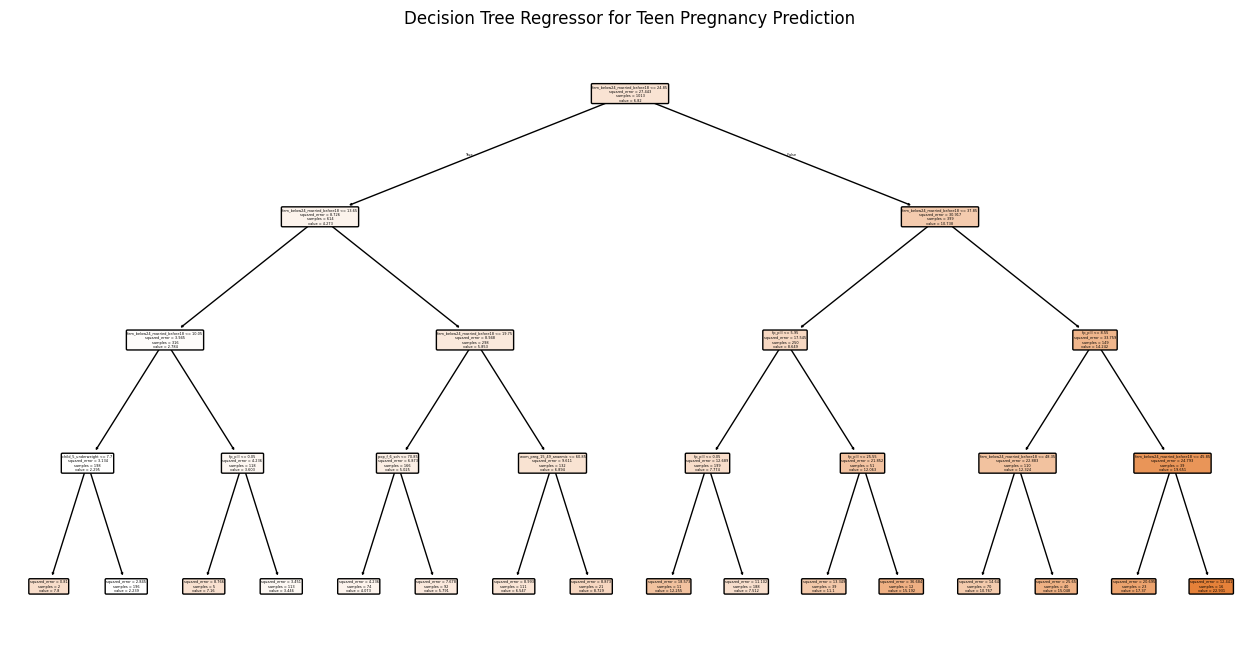

In [ ]:
plt.figure(figsize=(16,8))
plot_tree(model, feature_names=features, filled=True, rounded=True)
plt.title("Decision Tree Regressor for Teen Pregnancy Prediction")
plt.show()


/tmp/ipython-input-3862596576.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp, palette='viridis')


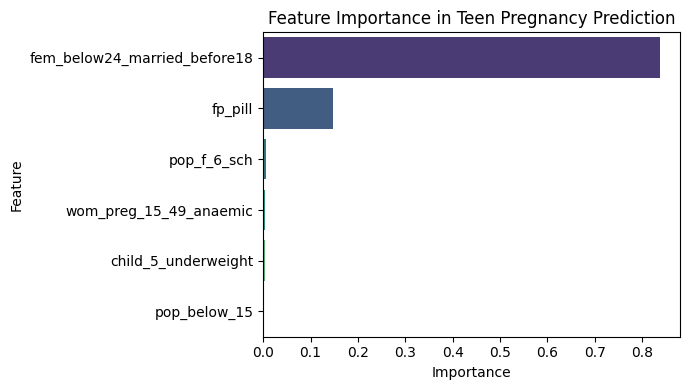

In [ ]:
imp = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x='Importance', y='Feature', data=imp, palette='viridis')
plt.title("Feature Importance in Teen Pregnancy Prediction")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R²:", r2_score(y_test, y_pred_rf))


Random Forest R²: 0.5729272721202789


#DECISION TREE

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define predictors and target
features = [
    'pop_f_6_sch',               # Female education
    'fem_below24_married_before18',  # Early marriage
    'fem_15_19_pregnant',        # Teenage pregnancy
    'wom_preg_15_49_anaemic',    # Women anaemia
    'fp_pill',                   # Family planning (pill use)
    'pop_below_15'               # Child population
]
target = 'child_5_underweight'

# Drop missing values
X = df[features].dropna()
y = df.loc[X.index, target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model_child = DecisionTreeRegressor(max_depth=4, random_state=42)
model_child.fit(X_train, y_train)

# Predictions
y_pred_child = model_child.predict(X_test)

# Evaluation
r2_child = r2_score(y_test, y_pred_child)
rmse_child = np.sqrt(mean_squared_error(y_test, y_pred_child))

print("📊 Decision Tree – Child Malnutrition")
print(f"R² Score: {r2_child:.3f}")
print(f"RMSE: {rmse_child:.3f}")


📊 Decision Tree – Child Malnutrition
R² Score: 0.398
RMSE: 8.634


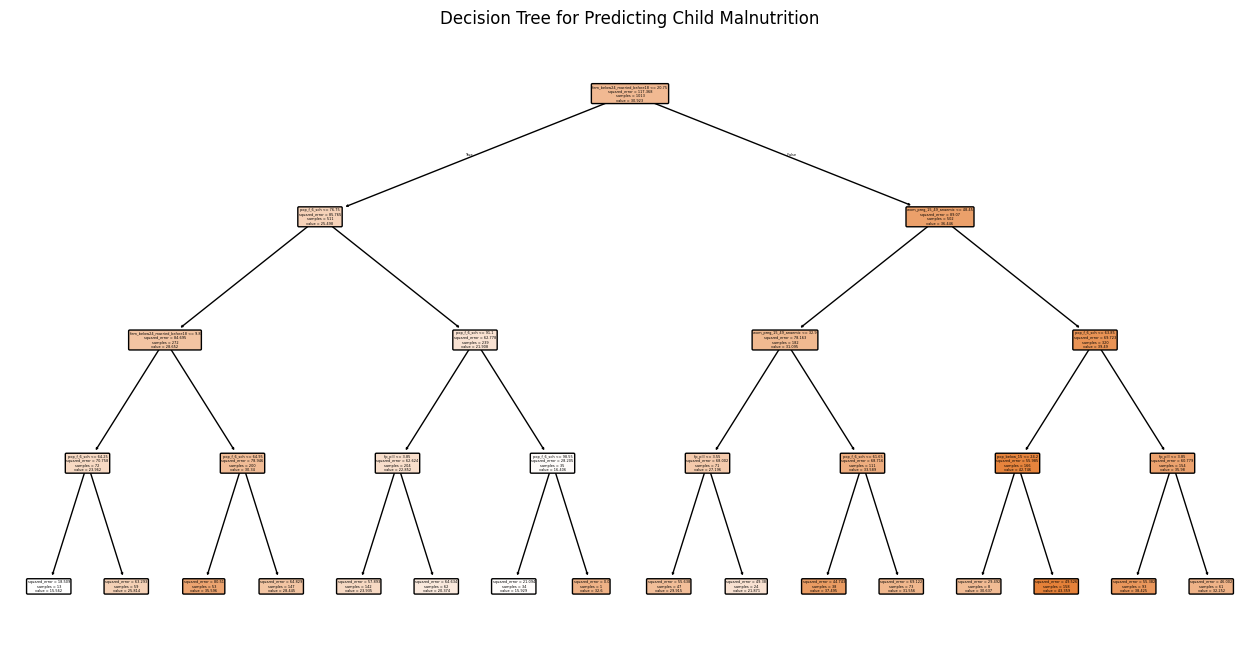

In [ ]:
plt.figure(figsize=(16,8))
plot_tree(model_child, feature_names=features, filled=True, rounded=True)
plt.title("Decision Tree for Predicting Child Malnutrition")
plt.show()


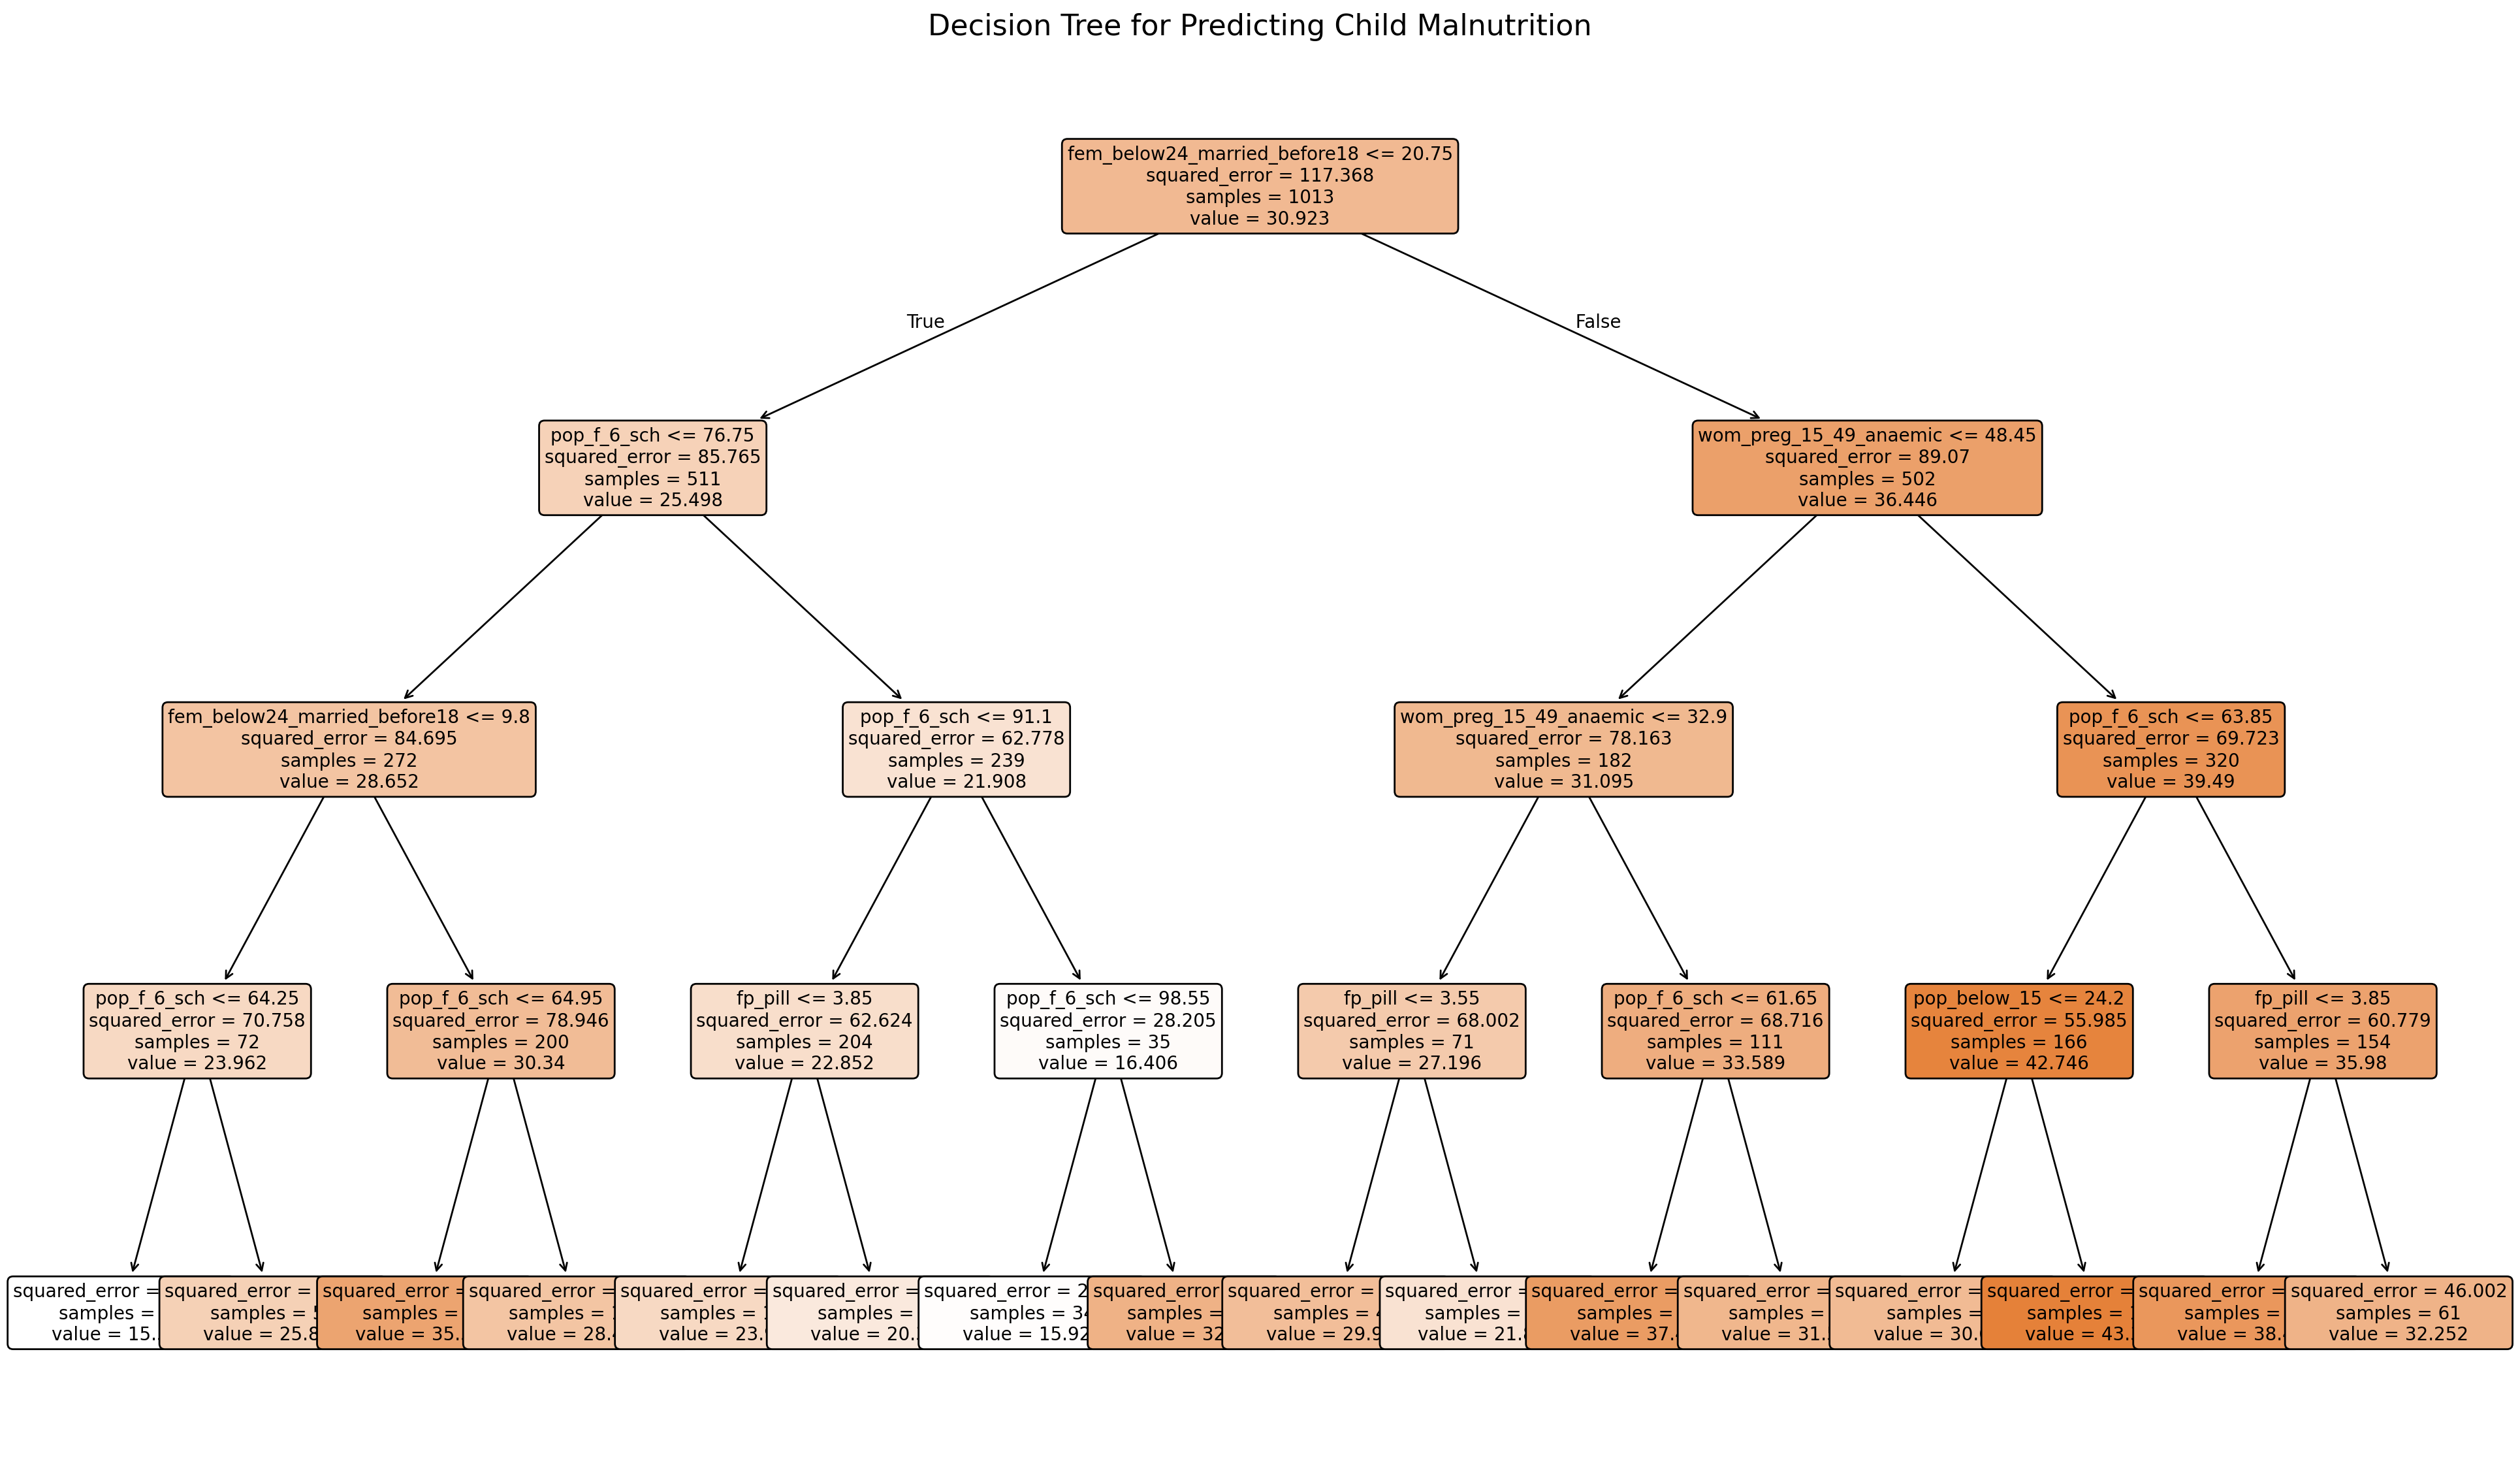

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 14), dpi=200)  # ⬅️ Larger size + high resolution
plot_tree(
    model_child,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Predicting Child Malnutrition", fontsize=16)
plt.show()


/tmp/ipython-input-1481076547.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_child, palette='crest')


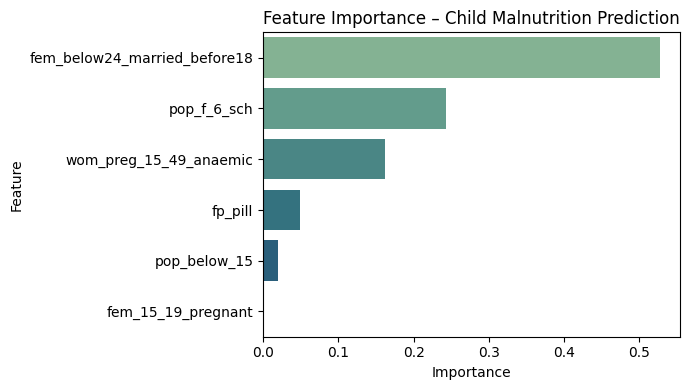

,Feature,Importance
1,fem_below24_married_before18,0.527620
0,pop_f_6_sch,0.242605
3,wom_preg_15_49_anaemic,0.161431
4,fp_pill,0.048342
5,pop_below_15,0.020002
2,fem_15_19_pregnant,0.000000


In [ ]:
imp_child = pd.DataFrame({
    'Feature': features,
    'Importance': model_child.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x='Importance', y='Feature', data=imp_child, palette='crest')
plt.title("Feature Importance – Child Malnutrition Prediction")
plt.tight_layout()
plt.show()

imp_child


#LOGISTIC REGRESSION

In [ ]:
df['high_bp_risk'] = (df['men_bp_sev'] > df['men_bp_sev'].median()).astype(int)


In [ ]:
features = [
    'tobaco_men_15',
    'alcohol_men_15',
    'tobaco_women_15',
    'alcohol_women_15',
    'oral_cancer',
    'cerv_cancer'
]
target = 'high_bp_risk'


📈 Logistic Regression – Men’s High BP Risk
Accuracy: 0.925
              precision    recall  f1-score   support

           0       0.95      0.90      0.93       132
           1       0.90      0.95      0.92       122

    accuracy                           0.93       254
   macro avg       0.93      0.93      0.93       254
weighted avg       0.93      0.93      0.93       254



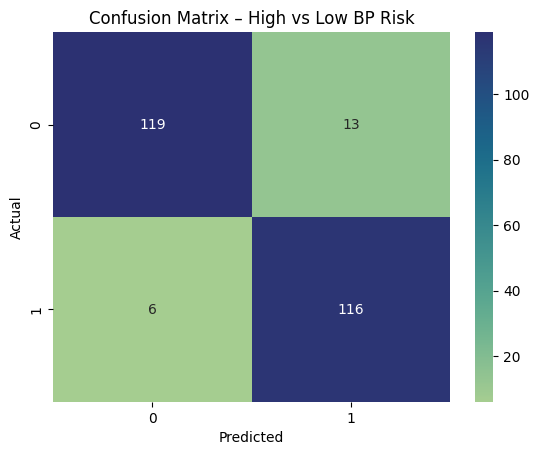

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing rows
X = df[features].dropna()
y = df.loc[X.index, target]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predict
y_pred = log_model.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("📈 Logistic Regression – Men’s High BP Risk")
print(f"Accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='crest')
plt.title("Confusion Matrix – High vs Low BP Risk")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
